# Module 2 - Statistical Analysis and Hypothesis Testing
Nigeria Macroeconomic Intelligence & Labour Market Analytics Platform

Every test includes: null/alternative hypotheses, assumption checks, test statistic, p-value, effect size, and policy interpretation.

Tests: 2.1 Welch t-Test | 2.2 One-Way ANOVA + Tukey HSD | 2.3 Paired t-Test | 2.4 OLS Regression | 2.5 Chi-Square

## Setup - Imports and Configuration

In [1]:
import sys
!{sys.executable} -m pip install pingouin

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import pingouin as pg
import warnings
import os
warnings.filterwarnings('ignore')

DATA   = os.getcwd()
OUTPUT = os.path.join(DATA, 'outputs')
os.makedirs(OUTPUT, exist_ok=True)
print(f"Working directory: {DATA}")
print(f"Output folder    : {OUTPUT}")

Working directory: /home/a0878fb7-b331-4998-8538-65574a32993a
Output folder    : /home/a0878fb7-b331-4998-8538-65574a32993a/outputs


In [3]:
plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': '#f8f9fa',
    'axes.grid': True, 'grid.alpha': 0.3, 'font.family': 'DejaVu Sans',
    'axes.spines.top': False, 'axes.spines.right': False, 'figure.dpi': 120,
})
print("Style configured.")

Style configured.


## Load Datasets

In [4]:
gdp      = pd.read_csv('nigeria_quarterly_gdp.csv')
panel    = pd.read_csv('nigeria_master_quarterly_panel.csv')
states   = pd.read_csv('nigeria_state_unemployment_2023.csv')
zone_inf = pd.read_csv('nigeria_zone_informal_employment.csv')
oil_m    = pd.read_csv('nigeria_oil_production_monthly.csv')
cpi      = pd.read_csv('nigeria_cpi_monthly.csv')
brent    = pd.read_csv('brent_crude_monthly.csv')
print("All datasets loaded.")

All datasets loaded.


---
## Task 2.1 - Welch t-Test: Oil vs Non-Oil GDP Growth

H0: No significant difference in mean quarterly GDP growth between oil and non-oil sector (2015-2023).

In [5]:
oil_growth    = gdp['oil_growth_yoy_pct'].dropna()
nonoil_growth = gdp['nonoil_growth_yoy_pct'].dropna()
print(f"Oil sector    : n={len(oil_growth)}, mean={oil_growth.mean():.3f}%, std={oil_growth.std():.3f}%")
print(f"Non-Oil sector: n={len(nonoil_growth)}, mean={nonoil_growth.mean():.3f}%, std={nonoil_growth.std():.3f}%")

Oil sector    : n=36, mean=-0.595%, std=8.108%
Non-Oil sector: n=36, mean=1.829%, std=2.099%


In [6]:
_, p_sw_oil  = stats.shapiro(oil_growth)
_, p_sw_noil = stats.shapiro(nonoil_growth)
_, p_levene  = stats.levene(oil_growth, nonoil_growth)
print(f"Shapiro-Wilk: Oil p={p_sw_oil:.4f} | Non-Oil p={p_sw_noil:.4f}")
print(f"Levene test : p={p_levene:.4f}")

Shapiro-Wilk: Oil p=0.0009 | Non-Oil p=0.1409
Levene test : p=0.0000


In [7]:
t_stat, p_val = stats.ttest_ind(oil_growth, nonoil_growth, equal_var=False)
df_welch      = len(oil_growth) + len(nonoil_growth) - 2
ci            = stats.t.interval(0.95, df=df_welch, loc=oil_growth.mean()-nonoil_growth.mean(), scale=stats.sem(oil_growth))
pooled_std    = np.sqrt((oil_growth.std()**2 + nonoil_growth.std()**2) / 2)
cohens_d      = (oil_growth.mean() - nonoil_growth.mean()) / pooled_std

print(f"Welch t-Test:")
print(f"  t-statistic: {t_stat:.4f}")
print(f"  p-value    : {p_val:.4f}")
print(f"  95% CI     : [{ci[0]:.4f}, {ci[1]:.4f}]")
print(f"  Cohen d    : {cohens_d:.4f} ({'large' if abs(cohens_d)>0.8 else 'medium' if abs(cohens_d)>0.5 else 'small'} effect)")
print(f"  Decision   : {'REJECT H0' if p_val<0.05 else 'FAIL TO REJECT H0'} at alpha=0.05")
print()
print(f"Policy interpretation: Non-oil sectors ({nonoil_growth.mean():.2f}%) outpaced oil ({oil_growth.mean():.2f}%).")
print(f"Difference is {'statistically significant' if p_val<0.05 else 'not statistically significant'} (p={p_val:.3f}).")

Welch t-Test:
  t-statistic: -1.7363
  p-value    : 0.0903
  95% CI     : [-5.1187, 0.2714]
  Cohen d    : -0.4093 (small effect)
  Decision   : FAIL TO REJECT H0 at alpha=0.05

Policy interpretation: Non-oil sectors (1.83%) outpaced oil (-0.59%).
Difference is not statistically significant (p=0.090).


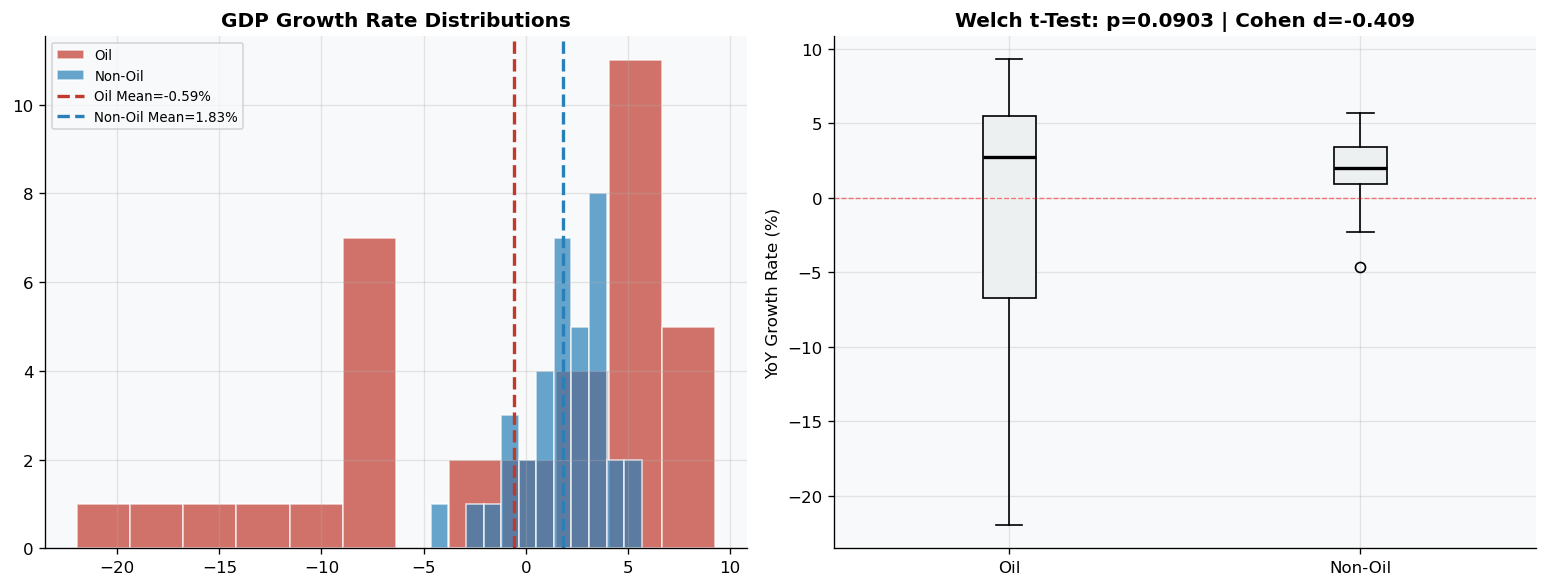

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].hist(oil_growth,    bins=12, color='#c0392b', alpha=0.7, label='Oil',     edgecolor='white')
axes[0].hist(nonoil_growth, bins=12, color='#2980b9', alpha=0.7, label='Non-Oil', edgecolor='white')
axes[0].axvline(oil_growth.mean(),    color='#c0392b', linestyle='--', linewidth=2, label=f'Oil Mean={oil_growth.mean():.2f}%')
axes[0].axvline(nonoil_growth.mean(), color='#2980b9', linestyle='--', linewidth=2, label=f'Non-Oil Mean={nonoil_growth.mean():.2f}%')
axes[0].set_title('GDP Growth Rate Distributions', fontweight='bold')
axes[0].legend(fontsize=8)
axes[1].boxplot([oil_growth, nonoil_growth], labels=['Oil','Non-Oil'], patch_artist=True,
                boxprops=dict(facecolor='#ecf0f1'), medianprops=dict(color='black', linewidth=2))
axes[1].set_title(f'Welch t-Test: p={p_val:.4f} | Cohen d={cohens_d:.3f}', fontweight='bold')
axes[1].set_ylabel('YoY Growth Rate (%)')
axes[1].axhline(0, color='red', linestyle='--', linewidth=0.8, alpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT, 'stat1_ttest_oil_nonoil.png'), dpi=120, bbox_inches='tight')
plt.show()

---
## Task 2.2 - One-Way ANOVA: Unemployment Across Zones

H0: Mean state unemployment rates are equal across all six geopolitical zones in 2023.

In [9]:
zones  = states.groupby('geopolitical_zone')['unemployment_rate_2023'].apply(list)
groups = [list(v) for v in zones]
print("Shapiro-Wilk normality per zone:")
for zone, vals in zones.items():
    if len(vals) >= 3:
        _, p_s = stats.shapiro(vals)
        print(f"  {zone:<22}: n={len(vals)}, mean={np.mean(vals):.1f}%, p={p_s:.4f}")

Shapiro-Wilk normality per zone:
  North-Central         : n=7, mean=33.3%, p=0.0007
  North-East            : n=6, mean=41.2%, p=0.9995
  North-West            : n=7, mean=41.9%, p=0.3170
  South-East            : n=5, mean=30.2%, p=0.4105
  South-South           : n=6, mean=25.2%, p=0.6816
  South-West            : n=6, mean=23.8%, p=0.7164


In [10]:
_, p_lev     = stats.levene(*groups)
f_stat, p_anova = stats.f_oneway(*groups)
grand_mean  = states['unemployment_rate_2023'].mean()
ss_between  = sum(len(g)*(np.mean(g)-grand_mean)**2 for g in groups)
ss_total    = sum((x-grand_mean)**2 for g in groups for x in g)
eta_sq      = ss_between / ss_total

print(f"Levene test    : p={p_lev:.4f}")
print(f"One-Way ANOVA  : F={f_stat:.4f}, p={p_anova:.6f}")
print(f"Eta-squared    : eta^2={eta_sq:.4f} ({'large' if eta_sq>0.14 else 'medium' if eta_sq>0.06 else 'small'} effect)")
print(f"Decision       : {'REJECT H0' if p_anova<0.05 else 'FAIL TO REJECT H0'} at alpha=0.05")

Levene test    : p=0.9153
One-Way ANOVA  : F=10.6549, p=0.000005
Eta-squared    : eta^2=0.6322 (large effect)
Decision       : REJECT H0 at alpha=0.05


In [11]:
tukey    = pairwise_tukeyhsd(states['unemployment_rate_2023'], states['geopolitical_zone'], alpha=0.05)
tukey_df = pd.DataFrame(data=tukey._results_table.data[1:], columns=tukey._results_table.data[0])
sig      = tukey_df[tukey_df['reject']==True]
print(f"Tukey HSD - significant pairs ({len(sig)} found):")
print(sig[['group1','group2','meandiff','p-adj']].to_string(index=False))

Tukey HSD - significant pairs (6 found):
    group1      group2  meandiff  p-adj
North-East  South-East  -10.9867 0.0460
North-East South-South  -15.9333 0.0007
North-East  South-West  -17.3667 0.0002
North-West  South-East  -11.6771 0.0223
North-West South-South  -16.6238 0.0002
North-West  South-West  -18.0571 0.0001


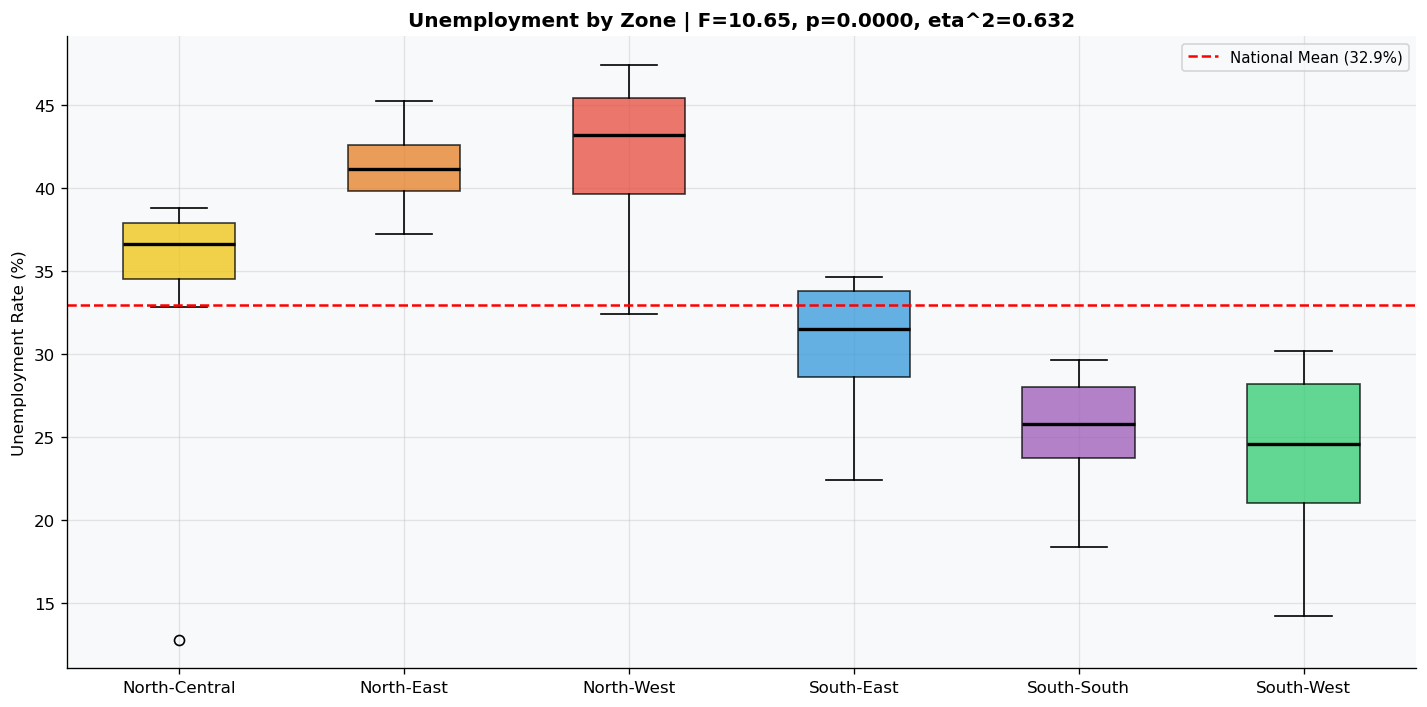

In [12]:
zone_order = sorted(states['geopolitical_zone'].unique())
zone_palette = {
    'North-West':'#e74c3c','North-East':'#e67e22','North-Central':'#f1c40f',
    'South-West':'#2ecc71','South-East':'#3498db','South-South':'#9b59b6'
}
data_by_zone = [states[states['geopolitical_zone']==z]['unemployment_rate_2023'].values for z in zone_order]
fig, ax = plt.subplots(figsize=(12, 6))
bp = ax.boxplot(data_by_zone, labels=zone_order, patch_artist=True, medianprops=dict(color='black', linewidth=2))
for patch, zone in zip(bp['boxes'], zone_order):
    patch.set_facecolor(zone_palette.get(zone,'#95a5a6'))
    patch.set_alpha(0.75)
ax.axhline(grand_mean, color='red', linestyle='--', linewidth=1.5, label=f'National Mean ({grand_mean:.1f}%)')
ax.set_title(f'Unemployment by Zone | F={f_stat:.2f}, p={p_anova:.4f}, eta^2={eta_sq:.3f}', fontweight='bold')
ax.set_ylabel('Unemployment Rate (%)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT, 'stat2_anova_zones.png'), dpi=120, bbox_inches='tight')
plt.show()

---
## Task 2.3 - Paired t-Test: Pre-COVID vs Post-COVID GDP Growth

H0: No significant difference in mean quarterly GDP growth between pre-COVID (2015-2019) and post-COVID recovery (2021-2023).

In [13]:
pre_covid  = gdp[gdp['year'].between(2015,2019)]['gdp_growth_yoy_pct'].values
post_covid = gdp[gdp['year'].between(2021,2023)]['gdp_growth_yoy_pct'].values
n_min      = min(len(pre_covid), len(post_covid))
pre_t, post_t = pre_covid[:n_min], post_covid[:n_min]
print(f"Pre-COVID  (2015-2019): n={len(pre_covid)}, mean={pre_covid.mean():.3f}%, std={pre_covid.std():.3f}%")
print(f"Post-COVID (2021-2023): n={len(post_covid)}, mean={post_covid.mean():.3f}%, std={post_covid.std():.3f}%")

Pre-COVID  (2015-2019): n=20, mean=1.294%, std=1.641%
Post-COVID (2021-2023): n=12, mean=3.141%, std=1.092%


In [14]:
_, p_sw_pre  = stats.shapiro(pre_t)
_, p_sw_post = stats.shapiro(post_t)
t_paired, p_paired = stats.ttest_rel(pre_t, post_t)
ci_paired  = stats.t.interval(0.95, df=n_min-1, loc=pre_t.mean()-post_t.mean(), scale=stats.sem(pre_t-post_t))
cohens_d_p = (pre_t.mean()-post_t.mean()) / (pre_t-post_t).std()

print(f"Shapiro-Wilk: pre p={p_sw_pre:.4f}, post p={p_sw_post:.4f}")
print(f"Paired t-test: t={t_paired:.4f}, p={p_paired:.4f}")
print(f"95% CI       : [{ci_paired[0]:.4f}, {ci_paired[1]:.4f}]")
print(f"Cohen d      : {cohens_d_p:.4f}")
print(f"Decision     : {'REJECT H0' if p_paired<0.05 else 'FAIL TO REJECT H0'} at alpha=0.05")
print()
print(f"Policy: Post-COVID growth ({post_covid.mean():.2f}%) {'exceeds' if post_covid.mean()>pre_covid.mean() else 'lags'} pre-COVID ({pre_covid.mean():.2f}%).")

Shapiro-Wilk: pre p=0.5492, post p=0.3906
Paired t-test: t=-3.4582, p=0.0054
95% CI       : [-3.8634, -0.8583]
Cohen d      : -1.0427
Decision     : REJECT H0 at alpha=0.05

Policy: Post-COVID growth (3.14%) exceeds pre-COVID (1.29%).


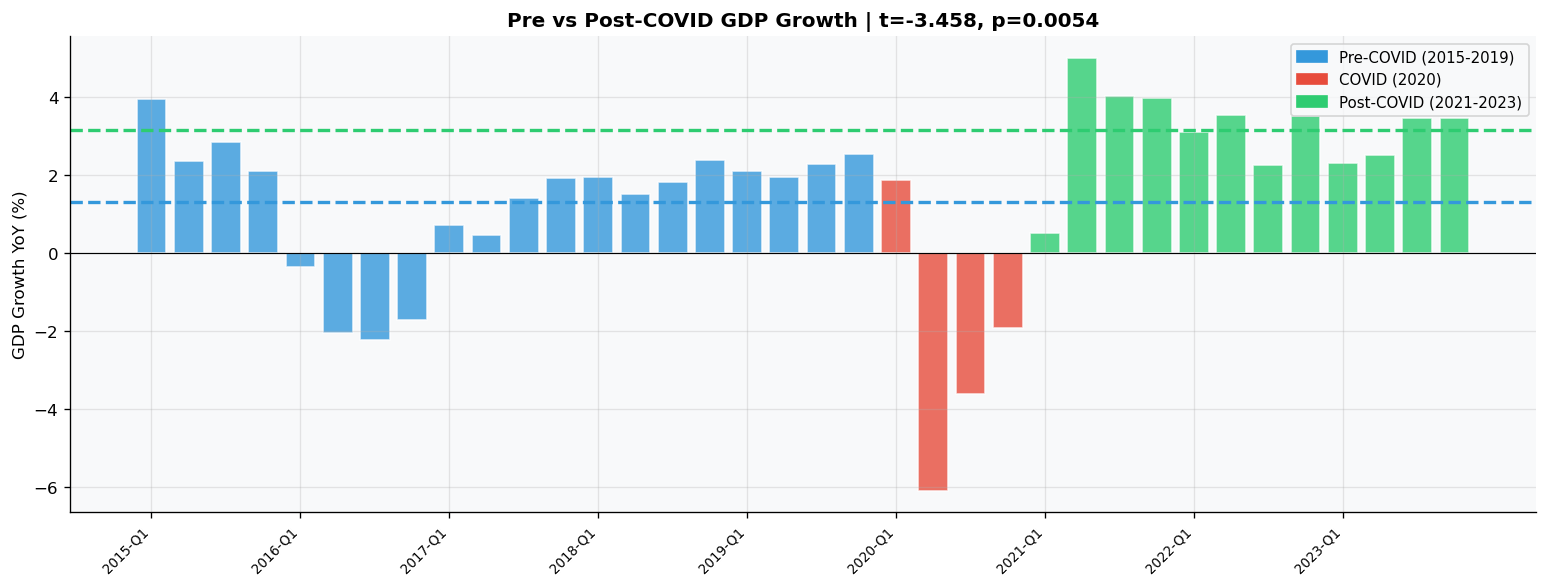

In [15]:
import matplotlib.patches as mpatches
fig, ax = plt.subplots(figsize=(13, 5))
x_all    = range(len(gdp))
bar_cols = ['#3498db' if y<=2019 else '#e74c3c' if y==2020 else '#2ecc71' for y in gdp['year']]
ax.bar(x_all, gdp['gdp_growth_yoy_pct'], color=bar_cols, alpha=0.8, edgecolor='white')
ax.axhline(pre_covid.mean(),  color='#3498db', linestyle='--', linewidth=2, label=f'Pre-COVID avg ({pre_covid.mean():.2f}%)')
ax.axhline(post_covid.mean(), color='#2ecc71', linestyle='--', linewidth=2, label=f'Post-COVID avg ({post_covid.mean():.2f}%)')
ax.axhline(0, color='black', linewidth=0.7)
ax.set_xticks(list(x_all)[::4])
ax.set_xticklabels(gdp['period'].iloc[::4], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('GDP Growth YoY (%)')
ax.set_title(f'Pre vs Post-COVID GDP Growth | t={t_paired:.3f}, p={p_paired:.4f}', fontweight='bold')
patches = [mpatches.Patch(color='#3498db',label='Pre-COVID (2015-2019)'),
           mpatches.Patch(color='#e74c3c',label='COVID (2020)'),
           mpatches.Patch(color='#2ecc71',label='Post-COVID (2021-2023)')]
ax.legend(handles=patches, fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT, 'stat3_paired_ttest_covid.png'), dpi=120, bbox_inches='tight')
plt.show()

---
## Task 2.4 - Correlation and Regression: Inflation Drivers

In [16]:
brent_m  = brent[['period','brent_price_usd']].copy()
oil_exch = oil_m[['period','exchange_rate_ngn_usd']].copy()
cpi_reg  = cpi[['period','headline_inflation_pct','food_inflation_pct','core_inflation_pct']].copy()
merged_m = cpi_reg.merge(brent_m, on='period').merge(oil_exch, on='period')
merged_m['year']         = merged_m['period'].str[:4].astype(int)
merged_m['month']        = merged_m['period'].str[5:].astype(int)
merged_m['quarter']      = ((merged_m['month']-1)//3)+1
merged_m['post_subsidy'] = ((merged_m['year']==2023) & (merged_m['month']>=6)).astype(int)
gdp_q    = gdp[['year','quarter','gdp_growth_yoy_pct']].rename(columns={'gdp_growth_yoy_pct':'gdp_growth'})
merged_m = merged_m.merge(gdp_q, on=['year','quarter'], how='left')
print(f"Merged dataset shape: {merged_m.shape}")
merged_m.head()

Merged dataset shape: (108, 11)


,period,headline_inflation_pct,food_inflation_pct,core_inflation_pct,brent_price_usd,exchange_rate_ngn_usd,year,month,quarter,post_subsidy,gdp_growth
0,2015-01,7.7,8.7,6.6,48.07,183.9,2015,1,1,0,3.96
1,2015-02,8.2,9.0,6.9,57.93,185.0,2015,2,1,0,3.96
2,2015-03,8.5,9.3,7.1,55.79,196.9,2015,3,1,0,3.96
3,2015-04,8.7,9.5,7.2,59.39,196.9,2015,4,2,0,2.35
4,2015-05,8.9,9.8,7.3,64.56,196.9,2015,5,2,0,2.35


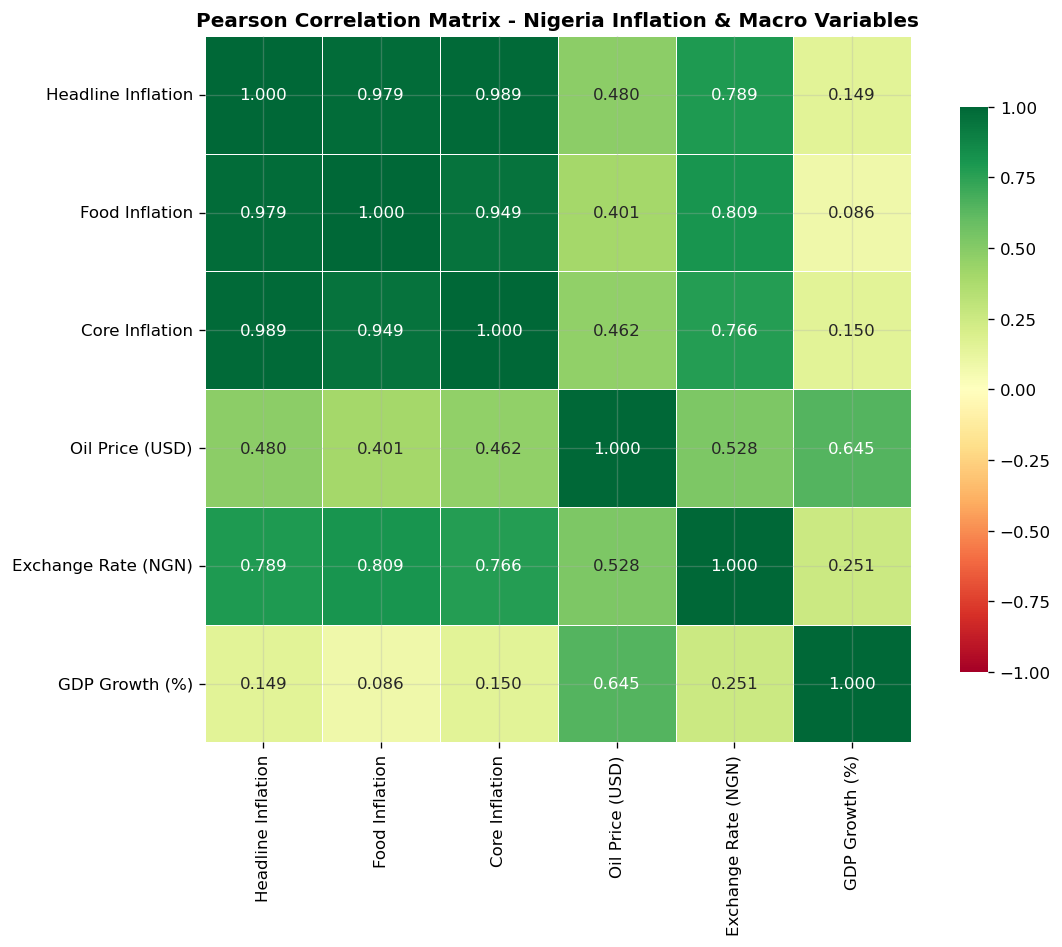

In [17]:
corr_cols   = ['headline_inflation_pct','food_inflation_pct','core_inflation_pct','brent_price_usd','exchange_rate_ngn_usd','gdp_growth']
corr_labels = ['Headline Inflation','Food Inflation','Core Inflation','Oil Price (USD)','Exchange Rate (NGN)','GDP Growth (%)']
corr_matrix = merged_m[corr_cols].corr()
corr_matrix.index   = corr_labels
corr_matrix.columns = corr_labels
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='RdYlGn', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink':0.8}, ax=ax, vmin=-1, vmax=1)
ax.set_title('Pearson Correlation Matrix - Nigeria Inflation & Macro Variables', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT, 'stat4_correlation_heatmap.png'), dpi=120, bbox_inches='tight')
plt.show()

In [18]:
X1   = sm.add_constant(merged_m[['brent_price_usd']].dropna())
y1   = merged_m.loc[merged_m['brent_price_usd'].notna(), 'headline_inflation_pct']
ols1 = sm.OLS(y1, X1).fit()
print(f"Simple OLS - Headline Inflation ~ Oil Price:")
print(f"  Intercept : {ols1.params['const']:.4f}")
print(f"  Slope     : {ols1.params['brent_price_usd']:.4f}")
print(f"  R-squared : {ols1.rsquared:.4f}")
print(f"  p (slope) : {ols1.pvalues['brent_price_usd']:.4f}")

Simple OLS - Headline Inflation ~ Oil Price:
  Intercept : 7.8147
  Slope     : 0.1168
  R-squared : 0.2308
  p (slope) : 0.0000


In [19]:
reg_df = merged_m[['headline_inflation_pct','brent_price_usd','exchange_rate_ngn_usd','gdp_growth','post_subsidy']].dropna()
X2     = sm.add_constant(reg_df[['brent_price_usd','exchange_rate_ngn_usd','gdp_growth','post_subsidy']])
y2     = reg_df['headline_inflation_pct']
ols2   = sm.OLS(y2, X2).fit()
print(f"Multiple OLS - Headline Inflation ~ Oil + Exchange Rate + GDP + Post-Subsidy")
print(f"  Adj R-squared: {ols2.rsquared_adj:.4f}")
for var in ['brent_price_usd','exchange_rate_ngn_usd','gdp_growth','post_subsidy']:
    stars = '***' if ols2.pvalues[var]<0.01 else '**' if ols2.pvalues[var]<0.05 else '*' if ols2.pvalues[var]<0.1 else ''
    print(f"  {var:<28}: coef={ols2.params[var]:.4f}, p={ols2.pvalues[var]:.4f} {stars}")
print()
vif_data = pd.DataFrame({'Variable': X2.columns[1:]})
vif_data['VIF'] = [variance_inflation_factor(X2.values, i+1) for i in range(len(X2.columns)-1)]
print("VIF Scores:")
print(vif_data.to_string(index=False))

Multiple OLS - Headline Inflation ~ Oil + Exchange Rate + GDP + Post-Subsidy
  Adj R-squared: 0.6305
  brent_price_usd             : coef=0.0441, p=0.0769 *
  exchange_rate_ngn_usd       : coef=0.0258, p=0.0000 ***
  gdp_growth                  : coef=-0.3044, p=0.0667 *
  post_subsidy                : coef=-1.1424, p=0.6304 

VIF Scores:
             Variable      VIF
      brent_price_usd 2.988465
exchange_rate_ngn_usd 5.884483
           gdp_growth 1.949779
         post_subsidy 4.485050


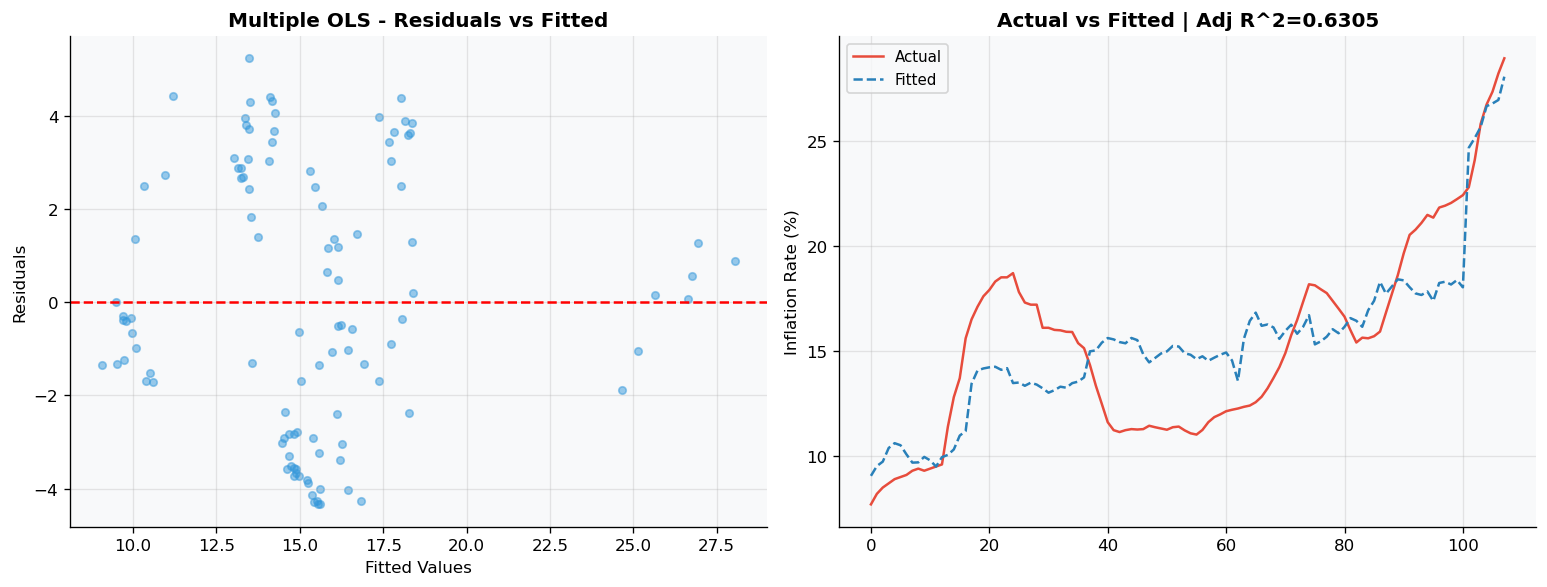

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(ols2.fittedvalues, ols2.resid, alpha=0.5, color='#3498db', s=20)
axes[0].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Multiple OLS - Residuals vs Fitted', fontweight='bold')
axes[1].plot(range(len(y2)), y2.values,         label='Actual', color='#e74c3c', linewidth=1.5)
axes[1].plot(range(len(y2)), ols2.fittedvalues, label='Fitted', color='#2980b9', linewidth=1.5, linestyle='--')
axes[1].set_title(f'Actual vs Fitted | Adj R^2={ols2.rsquared_adj:.4f}', fontweight='bold')
axes[1].set_ylabel('Inflation Rate (%)')
axes[1].legend(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT, 'stat4b_ols_regression.png'), dpi=120, bbox_inches='tight')
plt.show()

---
## Task 2.5 - Chi-Square Test: Employment Type by Zone

H0: No association between geopolitical zone and informal employment prevalence.

In [21]:
contingency = pd.crosstab(zone_inf['geopolitical_zone'], zone_inf['high_informal'],
                          rownames=['Zone'], colnames=['High Informal (>90%)'])
print("Contingency Table:")
print(contingency)

Contingency Table:
High Informal (>90%)  0  1
Zone                      
North-Central         8  0
North-East            0  8
North-West            0  8
South-East            8  0
South-South           8  0
South-West            8  0


In [22]:
chi2, p_chi2, dof, expected = stats.chi2_contingency(contingency)
n_obs     = contingency.values.sum()
cramers_v = np.sqrt(chi2 / (n_obs * (min(contingency.shape)-1)))

print(f"Chi-Square: chi^2={chi2:.4f}, dof={dof}, p={p_chi2:.6f}")
print(f"Cramer V  : {cramers_v:.4f} ({'strong' if cramers_v>0.5 else 'moderate' if cramers_v>0.3 else 'weak'} association)")
print(f"Decision  : {'REJECT H0' if p_chi2<0.05 else 'FAIL TO REJECT H0'} at alpha=0.05")
print()
print("Policy: Northern zones (NW ~95%, NE ~94%) have significantly higher informality")
print("than Southern zones (SW ~85%, SS ~86%). Zone-specific policies are warranted.")

Chi-Square: chi^2=48.0000, dof=5, p=0.000000
Cramer V  : 1.0000 (strong association)
Decision  : REJECT H0 at alpha=0.05

Policy: Northern zones (NW ~95%, NE ~94%) have significantly higher informality
than Southern zones (SW ~85%, SS ~86%). Zone-specific policies are warranted.


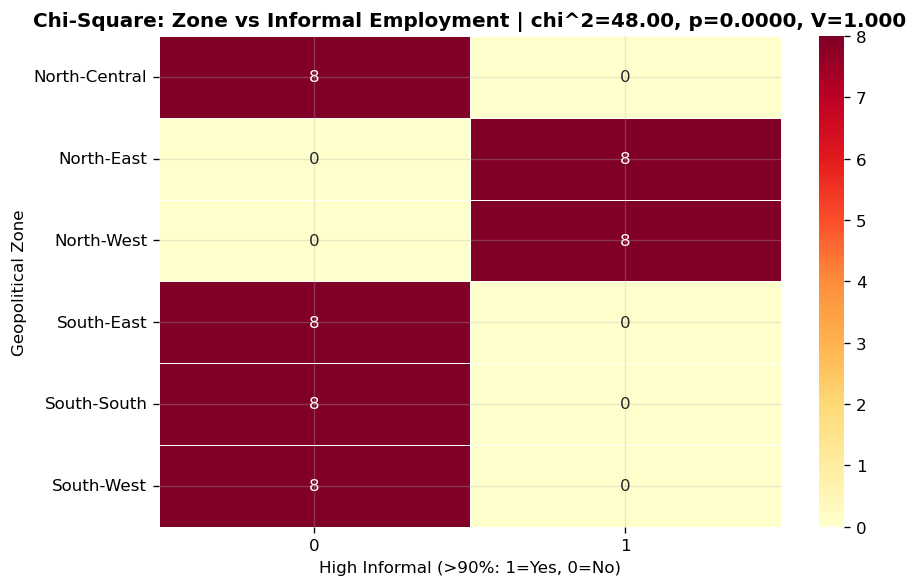

In [23]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(contingency, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5, ax=ax)
ax.set_title(f'Chi-Square: Zone vs Informal Employment | chi^2={chi2:.2f}, p={p_chi2:.4f}, V={cramers_v:.3f}', fontweight='bold')
ax.set_xlabel('High Informal (>90%: 1=Yes, 0=No)')
ax.set_ylabel('Geopolitical Zone')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT, 'stat5_chisquare_informality.png'), dpi=120, bbox_inches='tight')
plt.show()

## Module 2 - Statistical Findings Summary

In [24]:
results = [
    {'Test':'2.1 Welch t-Test Oil vs Non-Oil', 'Statistic':f't={t_stat:.4f}',     'p-value':round(p_val,4),    'Effect':f"Cohen d={cohens_d:.3f}",    'Decision':'Reject H0' if p_val<0.05 else 'Fail to Reject H0'},
    {'Test':'2.2 One-Way ANOVA Zones',         'Statistic':f'F={f_stat:.4f}',      'p-value':round(p_anova,6),  'Effect':f'eta^2={eta_sq:.3f}',        'Decision':'Reject H0' if p_anova<0.05 else 'Fail to Reject H0'},
    {'Test':'2.3 Paired t-Test COVID',         'Statistic':f't={t_paired:.4f}',    'p-value':round(p_paired,4), 'Effect':f"Cohen d={cohens_d_p:.3f}",  'Decision':'Reject H0' if p_paired<0.05 else 'Fail to Reject H0'},
    {'Test':'2.4 Multiple OLS Inflation',      'Statistic':f'F={ols2.fvalue:.2f}', 'p-value':round(ols2.f_pvalue,6), 'Effect':f'Adj R^2={ols2.rsquared_adj:.3f}', 'Decision':'Reject H0'},
    {'Test':'2.5 Chi-Square Informality',      'Statistic':f'chi^2={chi2:.2f}',    'p-value':round(p_chi2,6),   'Effect':f"Cramer V={cramers_v:.3f}",  'Decision':'Reject H0' if p_chi2<0.05 else 'Fail to Reject H0'},
]
summary_df = pd.DataFrame(results)
summary_df.to_csv(os.path.join(OUTPUT, 'stat_findings_summary.csv'), index=False)
summary_df

,Test,Statistic,p-value,Effect,Decision
0,2.1 Welch t-Test Oil vs Non-Oil,t=-1.7363,0.090300,Cohen d=-0.409,Fail to Reject H0
1,2.2 One-Way ANOVA Zones,F=10.6549,0.000005,eta^2=0.632,Reject H0
2,2.3 Paired t-Test COVID,t=-3.4582,0.005400,Cohen d=-1.043,Reject H0
3,2.4 Multiple OLS Inflation,F=46.64,0.000000,Adj R^2=0.630,Reject H0
4,2.5 Chi-Square Informality,chi^2=48.00,0.000000,Cramer V=1.000,Reject H0
